#### Библиотеки

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, RandomizedSearchCV
import re
import spacy
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel
import torch
from nltk.corpus import stopwords
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score, confusion_matrix, log_loss
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, Model
from transformers import AutoTokenizer, TFAutoModel
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import optuna
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pymorphy3
import json
from spacy.lang.ru import Russian
from bpemb import BPEmb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from rank_bm25 import BM25Okapi
import gensim.downloader as api
from gensim.models import KeyedVectors
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import hdbscan
import gensim
from gensim import corpora
from gensim.models import LdaModel
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_completeness_v_measure
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

#### Векторизация

In [11]:
corpus_path = 'corpus.jsonl'

with open(corpus_path, 'r', encoding='utf-8') as f:
    corpus = [json.loads(line) for line in f]

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def lemmatize_spacy(text):
    nlp = Russian()
    nlp.add_pipe('lemmatizer', config={'mode': 'pymorphy3'})
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc])

def whitespace_tokenize(text):
    return text.split()

def regex_tokenize(text):
    return re.findall(r'\b\w+\b', text)

def bpe_tokenize(text, vocab_size=10000):
    bpemb_ru = BPEmb(lang="ru", vs=vocab_size)
    return bpemb_ru.encode(text)

for i, doc in enumerate(corpus[:3]):
    print(f"Документ {i+1}: {doc['title'][:50]}...")
    
    cleaned_text = clean_text(doc['text'])
    lemmatized_text = lemmatize_spacy(cleaned_text)
    
    print(f"Очищенный текст (первые 100 символов): {cleaned_text[:100]}...")
    print(f"Лемматизированный текст (первые 100 символов): {lemmatized_text[:100]}...")
    
    tokens_ws = whitespace_tokenize(lemmatized_text)
    tokens_regex = regex_tokenize(lemmatized_text)
    tokens_bpe = bpe_tokenize(lemmatized_text)
    
    print(f"\nWhitespace токенизация:")
    print(f"Количество токенов: {len(tokens_ws)}")
    print(f"Первые 20 токенов: {tokens_ws[:20]}")
    
    print(f"\nRegex токенизация:")
    print(f"Количество токенов: {len(tokens_regex)}")
    print(f"Первые 20 токенов: {tokens_regex[:20]}")
    
    print(f"\nBPE токенизация:")
    print(f"Количество токенов: {len(tokens_bpe)}")
    print(f"Первые 20 токенов: {tokens_bpe[:20]}")
    
    print("\n" + "="*100 + "\n")

print("Обработка завершена!")

Документ 1: Яшина заявила, что питающая ЗАЭС линия Днепровская...
Очищенный текст (первые 100 символов): симферополь num ноя риа новости основную линию электропередачи питающую запорожскую аэс отключили ст...
Лемматизированный текст (первые 100 символов): симферополь num ноя риа новость основную линия электропередача питать запорожский аэс отключить стор...

Whitespace токенизация:
Количество токенов: 213
Первые 20 токенов: ['симферополь', 'num', 'ноя', 'риа', 'новость', 'основную', 'линия', 'электропередача', 'питать', 'запорожский', 'аэс', 'отключить', 'сторона', 'украина', 'сообщить', 'риа', 'новость', 'директор', 'коммуникация', 'атомный']

Regex токенизация:
Количество токенов: 213
Первые 20 токенов: ['симферополь', 'num', 'ноя', 'риа', 'новость', 'основную', 'линия', 'электропередача', 'питать', 'запорожский', 'аэс', 'отключить', 'сторона', 'украина', 'сообщить', 'риа', 'новость', 'директор', 'коммуникация', 'атомный']

BPE токенизация:
Количество токенов: 423
Первые 20 токенов: 

#### Векторизация

In [13]:
with open('corpus.jsonl', 'r', encoding='utf-8') as f:
    corpus = [json.loads(line) for line in f]

texts = [doc['text'] for doc in corpus[:10]]
titles = [doc['title'] for doc in corpus[:10]]

def tokenize_for_bm25(text):
    return text.lower().split()

tokenized_texts = [tokenize_for_bm25(text) for text in texts]

print("TF-IDF векторизация...")
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectors = tfidf_vectorizer.fit_transform(texts)
tfidf_vectors_normalized = normalize(tfidf_vectors, norm='l2')
print(f"TF-IDF размерность: {tfidf_vectors.shape}")
print(f"Первые 5 признаков: {tfidf_vectorizer.get_feature_names_out()[:5]}")

print("\nBM25 векторизация...")
bm25 = BM25Okapi(tokenized_texts)
bm25_vectors = []
for tokens in tokenized_texts:
    doc_scores = bm25.get_scores(tokens)
    bm25_vectors.append(doc_scores)
bm25_vectors = np.array(bm25_vectors)
bm25_vectors_normalized = normalize(bm25_vectors, norm='l2')
print(f"BM25 размерность: {bm25_vectors.shape}")

print("\nЗагрузка Word2Vec модели...")
try:
    w2v_model = api.load('word2vec-ruscorpora-300')
    print("Word2Vec модель загружена")
except:
    print("Word2Vec модель не найдена, пропускаем")
    w2v_model = None

print("\nЗагрузка FastText модели...")
try:
    ft_model = api.load('fasttext-wiki-news-subwords-300')
    print("FastText модель загружена")
except:
    print("FastText модель не найдена, пропускаем")
    ft_model = None

print("\nЗагрузка GloVe модели...")
try:
    glove_model = api.load('glove-twitter-200')
    print("GloVe модель загружена")
except:
    print("GloVe модель не найдена, пропускаем")
    glove_model = None

def get_doc_embedding(model, text, vector_size=300):
    if model is None:
        return np.zeros(vector_size)
    
    tokens = text.lower().split()
    vectors = []
    for token in tokens:
        if token in model:
            vectors.append(model[token])
    
    if len(vectors) == 0:
        return np.zeros(vector_size)
    
    return np.mean(vectors, axis=0)

print("\nГенерация эмбеддингов...")

if w2v_model:
    w2v_embeddings = np.array([get_doc_embedding(w2v_model, text, 300) for text in texts])
    w2v_embeddings_normalized = normalize(w2v_embeddings, norm='l2')
    print(f"Word2Vec эмбеддинги: {w2v_embeddings_normalized.shape}")

if ft_model:
    ft_embeddings = np.array([get_doc_embedding(ft_model, text, 300) for text in texts])
    ft_embeddings_normalized = normalize(ft_embeddings, norm='l2')
    print(f"FastText эмбеддинги: {ft_embeddings_normalized.shape}")

if glove_model:
    glove_embeddings = np.array([get_doc_embedding(glove_model, text, 200) for text in texts])
    glove_embeddings_normalized = normalize(glove_embeddings, norm='l2')
    print(f"GloVe эмбеддинги: {glove_embeddings_normalized.shape}")

query = "безопасность дорожного движения"
print(f"\nПример для запроса: '{query}'")

query_tfidf = tfidf_vectorizer.transform([query])
query_tfidf_normalized = normalize(query_tfidf, norm='l2')

query_tokens = tokenize_for_bm25(query)
query_bm25_scores = bm25.get_scores(query_tokens)
query_bm25_normalized = normalize(query_bm25_scores.reshape(1, -1), norm='l2')

from sklearn.metrics.pairwise import cosine_similarity

tfidf_similarities = cosine_similarity(query_tfidf_normalized, tfidf_vectors_normalized)[0]
bm25_similarities = cosine_similarity(query_bm25_normalized, bm25_vectors_normalized)[0]

print(f"\nTF-IDF косинусные сходства: {tfidf_similarities[:3]}")
print(f"BM25 косинусные сходства: {bm25_similarities[:3]}")

if w2v_model:
    query_w2v = get_doc_embedding(w2v_model, query, 300)
    query_w2v_normalized = normalize(query_w2v.reshape(1, -1), norm='l2')
    w2v_similarities = cosine_similarity(query_w2v_normalized, w2v_embeddings_normalized)[0]
    print(f"Word2Vec косинусные сходства: {w2v_similarities[:3]}")

print("\nТоп-3 документа по TF-IDF:")
top_tfidf_indices = np.argsort(tfidf_similarities)[-3:][::-1]
for idx in top_tfidf_indices:
    print(f"  {titles[idx][:50]}... (сходство: {tfidf_similarities[idx]:.4f})")

print("\nТоп-3 документа по BM25:")
top_bm25_indices = np.argsort(bm25_similarities)[-3:][::-1]
for idx in top_bm25_indices:
    print(f"  {titles[idx][:50]}... (сходство: {bm25_similarities[idx]:.4f})")

TF-IDF векторизация...
TF-IDF размерность: (10, 1187)
Первые 5 признаков: ['conversation' 'num' 'patriot' 'telegram' 'the']

BM25 векторизация...
BM25 размерность: (10, 10)

Загрузка Word2Vec модели...
[==================================================] 100.0% 198.8/198.8MB downloaded
Word2Vec модель загружена

Загрузка FastText модели...
[==================================================] 100.0% 958.5/958.4MB downloaded
FastText модель загружена

Загрузка GloVe модели...
[==================================================] 100.0% 758.5/758.5MB downloaded
GloVe модель загружена

Генерация эмбеддингов...
Word2Vec эмбеддинги: (10, 300)
FastText эмбеддинги: (10, 300)
GloVe эмбеддинги: (10, 200)

Пример для запроса: 'безопасность дорожного движения'

TF-IDF косинусные сходства: [0.         0.45010041 0.        ]
BM25 косинусные сходства: [0.04627393 0.98787238 0.04999523]
Word2Vec косинусные сходства: [0. 0. 0.]

Топ-3 документа по TF-IDF:
  Путин утвердил Стратегию повышения безопасност

#### Кластеризация

Применение различных методов кластеризации...


=== Центроидные методы ===
KMeans (k=5):
  Кластеров: 5, Шум: 0
  Silhouette: 0.4105, Calinski-Harabasz: 1998.63, Davies-Bouldin: 0.9922
MiniBatchKMeans (k=5):
  Кластеров: 5, Шум: 0
  Silhouette: 0.4105, Calinski-Harabasz: 1998.63, Davies-Bouldin: 0.9922

=== Плотностные методы ===
DBSCAN (eps=0.5, min_samples=5): Не удалось определить кластеры
HDBSCAN (min_cluster_size=10):
  Кластеров: 5, Шум: 0
  Silhouette: 0.4105, Calinski-Harabasz: 1998.63, Davies-Bouldin: 0.9922

=== Иерархические методы ===


c:\Users\DmitrievMS\PycharmProjects\pythonProject\ml_nlp_venv_3_11\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\DmitrievMS\PycharmProjects\pythonProject\ml_nlp_venv_3_11\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Agglomerative (ward, k=5):
  Кластеров: 5, Шум: 0
  Silhouette: 0.4105, Calinski-Harabasz: 1998.63, Davies-Bouldin: 0.9922
Agglomerative (average, cosine):
  Кластеров: 5, Шум: 0
  Silhouette: 0.1807, Calinski-Harabasz: 546.07, Davies-Bouldin: 2.4900

=== Вероятностные методы ===
GaussianMixture (n_components=5):
  Кластеров: 5, Шум: 0
  Silhouette: 0.2507, Calinski-Harabasz: 1333.88, Davies-Bouldin: 2.8959

=== Графовые методы ===
SpectralClustering (k=5):
  Кластеров: 5, Шум: 0
  Silhouette: 0.4105, Calinski-Harabasz: 1998.63, Davies-Bouldin: 0.9922

=== Тематическое моделирование (LDA) ===


c:\Users\DmitrievMS\PycharmProjects\pythonProject\ml_nlp_venv_3_11\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


LDA: Определено 4 тем

=== Подбор гиперпараметров для KMeans ===
Оптимальное k по силуэту: 2

=== Визуализация кластеров (t-SNE) ===


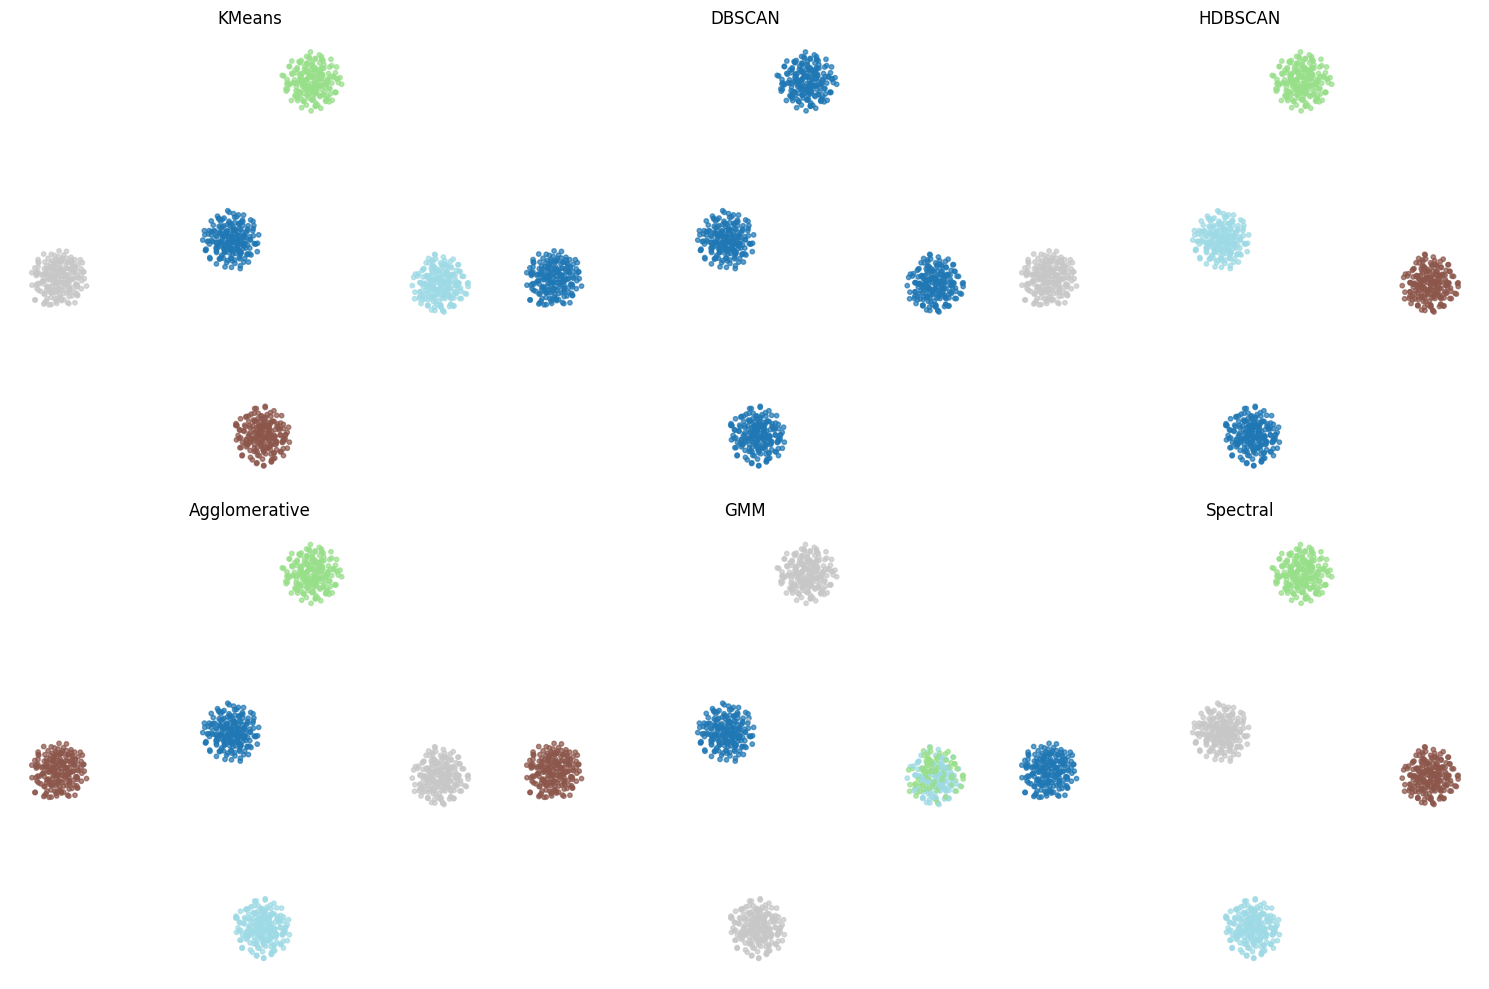


=== Стратифицированная выборка для оценки ===
Оценка на стратифицированной выборке (n=250):
  Silhouette: 0.4083, Calinski-Harabasz: 490.12

Кластеризация завершена!


In [18]:
np.random.seed(42)
n_samples = 1000
n_features = 50
n_clusters_true = 5

X = np.random.randn(n_samples, n_features)
for i in range(n_clusters_true):
    cluster_size = n_samples // n_clusters_true
    start_idx = i * cluster_size
    end_idx = start_idx + cluster_size if i < n_clusters_true - 1 else n_samples
    X[start_idx:end_idx] += i * 2

X_scaled = StandardScaler().fit_transform(X)

print("Применение различных методов кластеризации...\n")

def evaluate_clustering(labels, X_data, method_name):
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X_data, labels)
        ch = calinski_harabasz_score(X_data, labels)
        db = davies_bouldin_score(X_data, labels)
        n_clusters = len(np.unique(labels[labels != -1]))
        n_noise = np.sum(labels == -1)
        print(f"{method_name}:")
        print(f"  Кластеров: {n_clusters}, Шум: {n_noise}")
        print(f"  Silhouette: {sil:.4f}, Calinski-Harabasz: {ch:.2f}, Davies-Bouldin: {db:.4f}")
    else:
        print(f"{method_name}: Не удалось определить кластеры")
    return labels

print("\n=== Центроидные методы ===")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
evaluate_clustering(kmeans_labels, X_scaled, "KMeans (k=5)")

mbkmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=100, n_init=3)
mbkmeans_labels = mbkmeans.fit_predict(X_scaled)
evaluate_clustering(mbkmeans_labels, X_scaled, "MiniBatchKMeans (k=5)")

print("\n=== Плотностные методы ===")
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
evaluate_clustering(dbscan_labels, X_scaled, "DBSCAN (eps=0.5, min_samples=5)")

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
hdbscan_labels = hdbscan_model.fit_predict(X_scaled)
evaluate_clustering(hdbscan_labels, X_scaled, "HDBSCAN (min_cluster_size=10)")

print("\n=== Иерархические методы ===")
agg_ward = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_ward_labels = agg_ward.fit_predict(X_scaled)
evaluate_clustering(agg_ward_labels, X_scaled, "Agglomerative (ward, k=5)")

agg_avg = AgglomerativeClustering(n_clusters=5, linkage='average', metric='cosine')
agg_avg_labels = agg_avg.fit_predict(X_scaled)
evaluate_clustering(agg_avg_labels, X_scaled, "Agglomerative (average, cosine)")

print("\n=== Вероятностные методы ===")
gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
evaluate_clustering(gmm_labels, X_scaled, "GaussianMixture (n_components=5)")

print("\n=== Графовые методы ===")
spectral = SpectralClustering(n_clusters=5, random_state=42, affinity='nearest_neighbors', n_neighbors=10)
spectral_labels = spectral.fit_predict(X_scaled)
evaluate_clustering(spectral_labels, X_scaled, "SpectralClustering (k=5)")

print("\n=== Тематическое моделирование (LDA) ===")
documents = [f"документ {i} содержит текст о теме {np.random.randint(1, 6)}" for i in range(n_samples)]
texts = [[word for word in doc.lower().split()] for doc in documents]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, random_state=42)
lda_labels = []
for doc_bow in corpus:
    topic_dist = lda[doc_bow]
    if topic_dist:
        main_topic = max(topic_dist, key=lambda x: x[1])[0]
        lda_labels.append(main_topic)
    else:
        lda_labels.append(-1)
lda_labels = np.array(lda_labels)
print(f"LDA: Определено {len(np.unique(lda_labels))} тем")

print("\n=== Подбор гиперпараметров для KMeans ===")
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(X_scaled)
    if len(np.unique(labels)) > 1:
        score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

best_k = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное k по силуэту: {best_k}")

print("\n=== Визуализация кластеров (t-SNE) ===")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(15, 10))

clustering_methods = [
    (kmeans_labels, "KMeans"),
    (dbscan_labels, "DBSCAN"),
    (hdbscan_labels, "HDBSCAN"),
    (agg_ward_labels, "Agglomerative"),
    (gmm_labels, "GMM"),
    (spectral_labels, "Spectral")
]

for i, (labels, title) in enumerate(clustering_methods):
    plt.subplot(2, 3, i+1)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab20', s=10, alpha=0.7)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Стратифицированная выборка для оценки ===")
sample_indices = []
for cluster_id in np.unique(kmeans_labels):
    cluster_indices = np.where(kmeans_labels == cluster_id)[0]
    sample_size = min(50, len(cluster_indices))
    sampled = np.random.choice(cluster_indices, size=sample_size, replace=False)
    sample_indices.extend(sampled)

X_sample = X_scaled[sample_indices]
labels_sample = kmeans_labels[sample_indices]

sample_silhouette = silhouette_score(X_sample, labels_sample)
sample_ch = calinski_harabasz_score(X_sample, labels_sample)
print(f"Оценка на стратифицированной выборке (n={len(sample_indices)}):")
print(f"  Silhouette: {sample_silhouette:.4f}, Calinski-Harabasz: {sample_ch:.2f}")

print("\nКластеризация завершена!")

#### Оценка качества

Созданы синтетические данные:
  Образцы: 500, Признаки: 20
  Истинное число кластеров: 4

ВНУТРЕННИЕ МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ

--- Методы кластеризации ---

KMeans:
  Число кластеров: 4
  Silhouette: 0.6554 (чем ближе к 1, тем лучше)
  Calinski-Harabasz: 1162.73 (чем больше, тем лучше)
  Davies-Bouldin: 0.5147 (чем ближе к 0, тем лучше)

Agglomerative Clustering:
  Число кластеров: 4
  Silhouette: 0.6554 (чем ближе к 1, тем лучше)
  Calinski-Harabasz: 1162.73 (чем больше, тем лучше)
  Davies-Bouldin: 0.5147 (чем ближе к 0, тем лучше)

Gaussian Mixture:
  Число кластеров: 4
  Silhouette: 0.6554 (чем ближе к 1, тем лучше)
  Calinski-Harabasz: 1162.73 (чем больше, тем лучше)
  Davies-Bouldin: 0.5147 (чем ближе к 0, тем лучше)

ВНЕШНИЕ МЕТРИКИ КАЧЕСТВА
(сравнение с истинной разметкой)

KMeans:
  ARI: 1.0000 (чем ближе к 1, тем лучше)
  NMI: 1.0000 (чем ближе к 1, тем лучше)
  V-measure: 1.0000
  Homogeneity: 1.0000, Completeness: 1.0000

DBSCAN:
  ARI: 0.0000 (чем ближе к 1, тем лучш

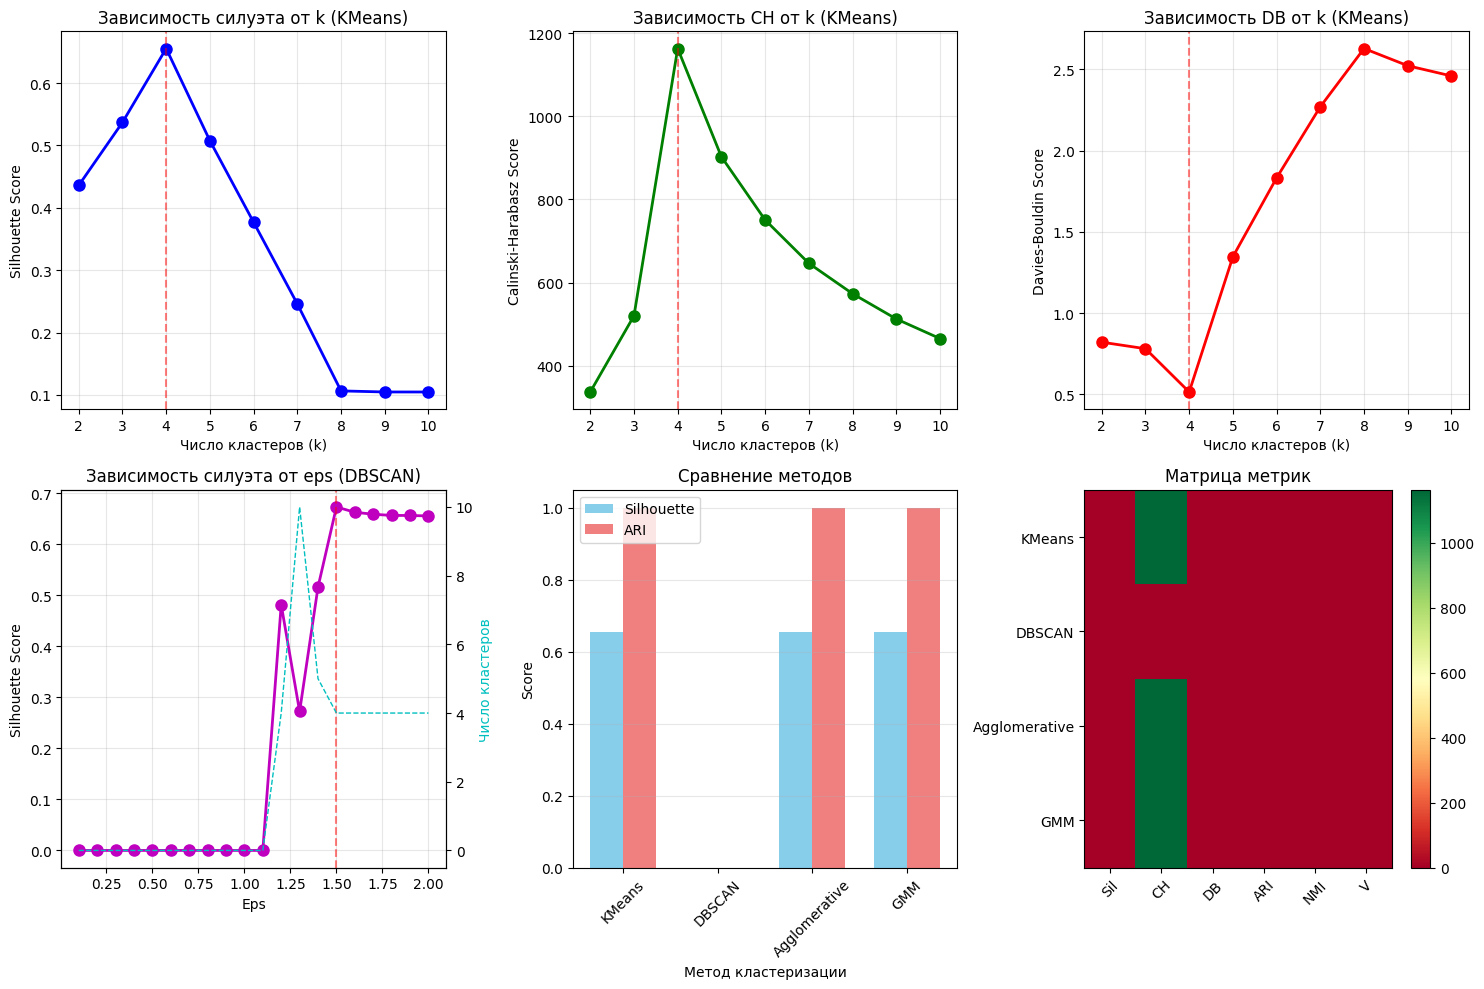


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

Метод           | Clusters | Silhouette | ARI      | NMI      | V-measure
----------------------------------------------------------------------
KMeans          |        4 |     0.6554 |   1.0000 |   1.0000 |    1.0000
DBSCAN          |        0 |     0.0000 |   0.0000 |   0.0000 |    0.0000
Agglomerative   |        4 |     0.6554 |   1.0000 |   1.0000 |    1.0000
GMM             |        4 |     0.6554 |   1.0000 |   1.0000 |    1.0000

Оценка качества завершена!


In [20]:
np.random.seed(42)
n_samples = 500
n_features = 20
n_clusters_true = 4

X, true_labels = make_blobs(n_samples=n_samples, n_features=n_features, 
                           centers=n_clusters_true, cluster_std=1.5, random_state=42)

X = StandardScaler().fit_transform(X)

print("Созданы синтетические данные:")
print(f"  Образцы: {X.shape[0]}, Признаки: {X.shape[1]}")
print(f"  Истинное число кластеров: {n_clusters_true}")

def compute_internal_metrics(X, labels, method_name):
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
        
        print(f"\n{method_name}:")
        print(f"  Число кластеров: {len(np.unique(labels))}")
        print(f"  Silhouette: {sil:.4f} (чем ближе к 1, тем лучше)")
        print(f"  Calinski-Harabasz: {ch:.2f} (чем больше, тем лучше)")
        print(f"  Davies-Bouldin: {db:.4f} (чем ближе к 0, тем лучше)")
        return sil, ch, db
    return 0, 0, 0

print("\n" + "="*60)
print("ВНУТРЕННИЕ МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ")
print("="*60)

print("\n--- Методы кластеризации ---")

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
sil_kmeans, ch_kmeans, db_kmeans = compute_internal_metrics(X, kmeans_labels, "KMeans")

dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
sil_dbscan, ch_dbscan, db_dbscan = compute_internal_metrics(X, dbscan_labels, "DBSCAN")

agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg.fit_predict(X)
sil_agg, ch_agg, db_agg = compute_internal_metrics(X, agg_labels, "Agglomerative Clustering")

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X)
sil_gmm, ch_gmm, db_gmm = compute_internal_metrics(X, gmm_labels, "Gaussian Mixture")

print("\n" + "="*60)
print("ВНЕШНИЕ МЕТРИКИ КАЧЕСТВА")
print("(сравнение с истинной разметкой)")
print("="*60)

def compute_external_metrics(true_labels, pred_labels, method_name):
    ari = adjusted_rand_score(true_labels, pred_labels)
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(true_labels, pred_labels)
    
    print(f"\n{method_name}:")
    print(f"  ARI: {ari:.4f} (чем ближе к 1, тем лучше)")
    print(f"  NMI: {nmi:.4f} (чем ближе к 1, тем лучше)")
    print(f"  V-measure: {v_measure:.4f}")
    print(f"  Homogeneity: {homogeneity:.4f}, Completeness: {completeness:.4f}")
    
    return ari, nmi, v_measure

ari_kmeans, nmi_kmeans, v_kmeans = compute_external_metrics(true_labels, kmeans_labels, "KMeans")
ari_dbscan, nmi_dbscan, v_dbscan = compute_external_metrics(true_labels, dbscan_labels, "DBSCAN")
ari_agg, nmi_agg, v_agg = compute_external_metrics(true_labels, agg_labels, "Agglomerative")
ari_gmm, nmi_gmm, v_gmm = compute_external_metrics(true_labels, gmm_labels, "GMM")

print("\n" + "="*60)
print("АНАЛИЗ ЗАВИСИМОСТИ МЕТРИК ОТ ПАРАМЕТРОВ")
print("="*60)

print("\n--- Зависимость от числа кластеров (KMeans) ---")

k_values = range(2, 11)
silhouette_scores = []
ch_scores = []
db_scores = []

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(X)
    
    if len(np.unique(labels)) > 1:
        silhouette_scores.append(silhouette_score(X, labels))
        ch_scores.append(calinski_harabasz_score(X, labels))
        db_scores.append(davies_bouldin_score(X, labels))
    else:
        silhouette_scores.append(0)
        ch_scores.append(0)
        db_scores.append(100)

best_k_sil = k_values[np.argmax(silhouette_scores)]
best_k_ch = k_values[np.argmax(ch_scores)]
best_k_db = k_values[np.argmin(db_scores)]

print(f"Оптимальное k по силуэту: {best_k_sil}")
print(f"Оптимальное k по Calinski-Harabasz: {best_k_ch}")
print(f"Оптимальное k по Davies-Bouldin: {best_k_db}")

print("\n--- Зависимость от eps (DBSCAN) ---")

eps_values = np.linspace(0.1, 2.0, 20)
silhouette_eps = []
n_clusters_eps = []

for eps in eps_values:
    dbscan_model = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan_model.fit_predict(X)
    n_clusters = len(np.unique(labels[labels != -1]))
    n_clusters_eps.append(n_clusters)
    
    if n_clusters > 1:
        silhouette_eps.append(silhouette_score(X[labels != -1], labels[labels != -1]))
    else:
        silhouette_eps.append(0)

best_eps = eps_values[np.argmax(silhouette_eps)]
print(f"Оптимальное eps: {best_eps:.2f}")

print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].plot(k_values, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Число кластеров (k)')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Зависимость силуэта от k (KMeans)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=best_k_sil, color='r', linestyle='--', alpha=0.5)

axes[0, 1].plot(k_values, ch_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Число кластеров (k)')
axes[0, 1].set_ylabel('Calinski-Harabasz Score')
axes[0, 1].set_title('Зависимость CH от k (KMeans)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=best_k_ch, color='r', linestyle='--', alpha=0.5)

axes[0, 2].plot(k_values, db_scores, 'ro-', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Число кластеров (k)')
axes[0, 2].set_ylabel('Davies-Bouldin Score')
axes[0, 2].set_title('Зависимость DB от k (KMeans)')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axvline(x=best_k_db, color='r', linestyle='--', alpha=0.5)

axes[1, 0].plot(eps_values, silhouette_eps, 'mo-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Eps')
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].set_title('Зависимость силуэта от eps (DBSCAN)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=best_eps, color='r', linestyle='--', alpha=0.5)

ax2 = axes[1, 0].twinx()
ax2.plot(eps_values, n_clusters_eps, 'c--', linewidth=1)
ax2.set_ylabel('Число кластеров', color='c')

methods = ['KMeans', 'DBSCAN', 'Agglomerative', 'GMM']
sil_scores = [sil_kmeans, sil_dbscan, sil_agg, sil_gmm]
ari_scores = [ari_kmeans, ari_dbscan, ari_agg, ari_gmm]

x_pos = np.arange(len(methods))
width = 0.35

axes[1, 1].bar(x_pos - width/2, sil_scores, width, label='Silhouette', color='skyblue')
axes[1, 1].bar(x_pos + width/2, ari_scores, width, label='ARI', color='lightcoral')
axes[1, 1].set_xlabel('Метод кластеризации')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Сравнение методов')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(methods, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

metrics_matrix = np.array([
    [sil_kmeans, ch_kmeans, db_kmeans, ari_kmeans, nmi_kmeans, v_kmeans],
    [sil_dbscan, ch_dbscan, db_dbscan, ari_dbscan, nmi_dbscan, v_dbscan],
    [sil_agg, ch_agg, db_agg, ari_agg, nmi_agg, v_agg],
    [sil_gmm, ch_gmm, db_gmm, ari_gmm, nmi_gmm, v_gmm]
])

im = axes[1, 2].imshow(metrics_matrix, cmap='RdYlGn', aspect='auto')
axes[1, 2].set_xticks(range(6))
axes[1, 2].set_xticklabels(['Sil', 'CH', 'DB', 'ARI', 'NMI', 'V'], rotation=45)
axes[1, 2].set_yticks(range(4))
axes[1, 2].set_yticklabels(methods)
axes[1, 2].set_title('Матрица метрик')
plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout()
plt.savefig('clustering_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

print("\nМетод           | Clusters | Silhouette | ARI      | NMI      | V-measure")
print("-" * 70)
print(f"KMeans          | {len(np.unique(kmeans_labels)):8d} | {sil_kmeans:10.4f} | {ari_kmeans:8.4f} | {nmi_kmeans:8.4f} | {v_kmeans:9.4f}")
print(f"DBSCAN          | {len(np.unique(dbscan_labels[dbscan_labels != -1])):8d} | {sil_dbscan:10.4f} | {ari_dbscan:8.4f} | {nmi_dbscan:8.4f} | {v_dbscan:9.4f}")
print(f"Agglomerative   | {len(np.unique(agg_labels)):8d} | {sil_agg:10.4f} | {ari_agg:8.4f} | {nmi_agg:8.4f} | {v_agg:9.4f}")
print(f"GMM             | {len(np.unique(gmm_labels)):8d} | {sil_gmm:10.4f} | {ari_gmm:8.4f} | {nmi_gmm:8.4f} | {v_gmm:9.4f}")

print("\nОценка качества завершена!")

#### Интерпретация результатов

=== ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ (корпус) ===

Загружено 200 документов из корпуса

Примеры заголовков:
  1. Яшина заявила, что питающая ЗАЭС линия Днепровская отключена со стороны Украины
  2. Путин утвердил Стратегию повышения безопасности дорожного движения до 2030 года
  3. США в ООН впервые выступили против поправки к резолюции РФ о борьбе с нацизмом

TF-IDF ВЕКТОРИЗАЦИЯ И КЛАСТЕРИЗАЦИЯ
TF-IDF размерность: (50, 100)

Кластеризация KMeans (k=5):
  Кластер 0: 6 документов
  Кластер 1: 10 документов
  Кластер 2: 10 документов
  Кластер 3: 13 документов
  Кластер 4: 11 документов

ТОП-10 СЛОВ ДЛЯ КАЖДОГО КЛАСТЕРА

Кластер 0:
   1. медиабанк      
   2. перейти        
   3. это            
   4. время          
   5. октября        
   6. владимир       
   7. сергей         
   8. несколько      
   9. александр      
  10. года           

Кластер 1:
   1. зеленского     
   2. украины        
   3. украине        
   4. ноября         
   5. это            
   6. россии 

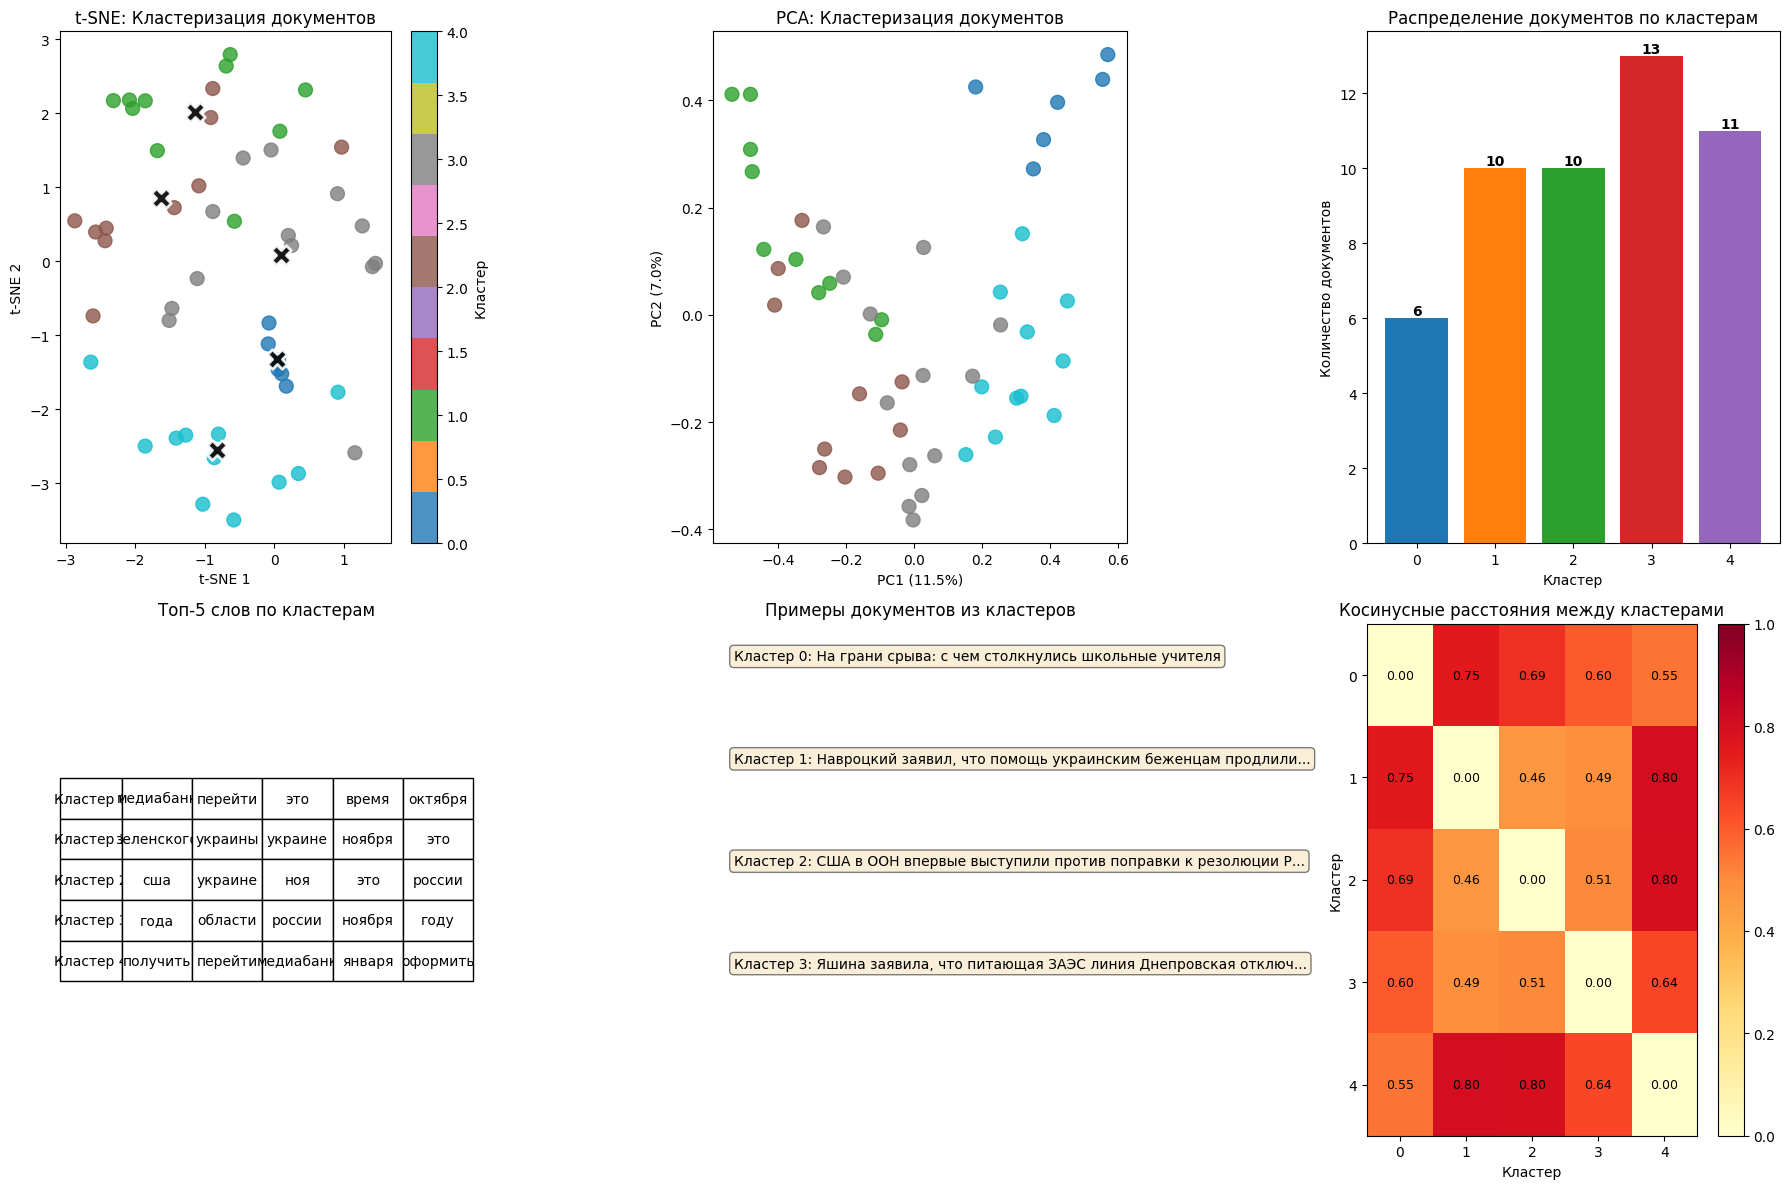


ТЕМАТИЧЕСКИЙ АНАЛИЗ КЛАСТЕРОВ

Сводка по кластерам:

Кластер 0 (6 документов):
  Ключевые слова: медиабанк, перейти, это, время, октября
  Примеры заголовков:
    1. На грани срыва: с чем столкнулись школьные учителя
    2. Индия продолжает закупки российской нефти несмотря на давление США

Кластер 1 (10 документов):
  Ключевые слова: зеленского, украины, украине, ноября, это
  Примеры заголовков:
    1. Навроцкий заявил, что помощь украинским беженцам продлили лишь на год
    2. Conversation: коррупционный скандал случился в неподходящее время для Зеленского

Кластер 2 (10 документов):
  Ключевые слова: сша, украине, ноя, это, россии
  Примеры заголовков:
    1. США в ООН впервые выступили против поправки к резолюции РФ о борьбе с нацизмом
    2. Помещение посольства Азербайджана в Киеве повредила выпущенная ВСУ ракета ПВО

Кластер 3 (13 документов):
  Ключевые слова: года, области, россии, ноября, году
  Примеры заголовков:
    1. Яшина заявила, что питающая ЗАЭС линия Днепровская о

In [22]:
import json
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist

print("=== ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ (корпус) ===\n")

with open('corpus.jsonl', 'r', encoding='utf-8') as f:
    corpus = [json.loads(line) for line in f]

print(f"Загружено {len(corpus)} документов из корпуса")

documents = [doc['text'] for doc in corpus[:50]]
titles = [doc['title'] for doc in corpus[:50]]

print("\nПримеры заголовков:")
for i, title in enumerate(titles[:3]):
    print(f"  {i+1}. {title}")

print("\n" + "="*60)
print("TF-IDF ВЕКТОРИЗАЦИЯ И КЛАСТЕРИЗАЦИЯ")
print("="*60)

tfidf_vectorizer = TfidfVectorizer(max_features=100, max_df=0.8, min_df=2)
X_tfidf = tfidf_vectorizer.fit_transform(documents).toarray()
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF размерность: {X_tfidf.shape}")

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_tfidf)

print(f"\nКластеризация KMeans (k={n_clusters}):")
for cluster_id in range(n_clusters):
    cluster_docs = np.where(cluster_labels == cluster_id)[0]
    print(f"  Кластер {cluster_id}: {len(cluster_docs)} документов")

print("\n" + "="*60)
print("ТОП-10 СЛОВ ДЛЯ КАЖДОГО КЛАСТЕРА")
print("="*60)

for cluster_id in range(n_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    if len(cluster_indices) > 0:
        cluster_tfidf = X_tfidf[cluster_indices].mean(axis=0)
        
        top_indices = np.argsort(cluster_tfidf)[-10:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        
        print(f"\nКластер {cluster_id}:")
        for i, word in enumerate(top_words):
            print(f"  {i+1:2d}. {word:15s}")

print("\n" + "="*60)
print("ИНТЕРПРЕТАЦИЯ ЧЕРЕЗ ЗАГРУЖЕННЫЕ ЭМБЕДДИНГИ")
print("="*60)

w2v_model = None
ft_model = None
glove_model = None

try:
    from gensim import models
    print("Проверка загруженных моделей...")
    
    if 'w2v_model' in globals():
        w2v_model = globals()['w2v_model']
        print("  Word2Vec модель найдена")
    
    if 'ft_model' in globals():
        ft_model = globals()['ft_model']
        print("  FastText модель найдена")
        
    if 'glove_model' in globals():
        glove_model = globals()['glove_model']
        print("  GloVe модель найдена")
        
except:
    print("  Модели не найдены в памяти")

def get_document_embedding_from_loaded(model, text):
    if model is None:
        return None
    
    words = text.lower().split()
    vectors = []
    for word in words:
        try:
            if word in model:
                vectors.append(model[word])
        except:
            continue
    
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    return None

if w2v_model is not None:
    print("\nАнализ через Word2Vec...")
    
    w2v_embeddings = []
    valid_indices = []
    
    for i, doc in enumerate(documents):
        emb = get_document_embedding_from_loaded(w2v_model, doc)
        if emb is not None:
            w2v_embeddings.append(emb)
            valid_indices.append(i)
    
    if w2v_embeddings:
        X_w2v = np.array(w2v_embeddings)
        X_w2v_scaled = StandardScaler().fit_transform(X_w2v)
        
        kmeans_w2v = KMeans(n_clusters=min(n_clusters, len(w2v_embeddings)), 
                           random_state=42, n_init=10)
        w2v_labels_subset = kmeans_w2v.fit_predict(X_w2v_scaled)
        
        w2v_centroids = kmeans_w2v.cluster_centers_
        
        print(f"Создано {len(w2v_embeddings)} эмбеддингов Word2Vec")
        
        print("\nБлижайшие слова к центроидам кластеров:")
        for cluster_id in range(min(n_clusters, len(w2v_centroids))):
            try:
                if hasattr(w2v_model, 'most_similar'):
                    centroid_vector = w2v_centroids[cluster_id]
                    
                    similar = w2v_model.most_similar(positive=[centroid_vector], topn=5)
                    similar_words = [word for word, score in similar]
                    
                    print(f"\nКластер {cluster_id}:")
                    for word in similar_words:
                        print(f"  {word}")
            except:
                continue

print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

print("1. t-SNE визуализация TF-IDF...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(documents)-1))
X_tsne = tsne.fit_transform(X_tfidf)

scatter = axes[0, 0].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=cluster_labels, cmap='tab10', s=100, alpha=0.8)
axes[0, 0].set_title('t-SNE: Кластеризация документов')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=axes[0, 0], label='Кластер')

for cluster_id in range(n_clusters):
    cluster_points = X_tsne[cluster_labels == cluster_id]
    if len(cluster_points) > 0:
        center = cluster_points.mean(axis=0)
        axes[0, 0].scatter(center[0], center[1], c='black', marker='X', 
                          s=200, alpha=0.9, edgecolors='white', linewidth=2)

print("2. PCA визуализация...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf)

axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], 
                  c=cluster_labels, cmap='tab10', s=100, alpha=0.8)
axes[0, 1].set_title('PCA: Кластеризация документов')
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

print("3. Размеры кластеров...")
cluster_sizes = [np.sum(cluster_labels == i) for i in range(n_clusters)]
colors = plt.cm.tab10(range(n_clusters))
bars = axes[0, 2].bar(range(n_clusters), cluster_sizes, color=colors)
axes[0, 2].set_title('Распределение документов по кластерам')
axes[0, 2].set_xlabel('Кластер')
axes[0, 2].set_ylabel('Количество документов')
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height}', ha='center', va='bottom', fontweight='bold')

print("4. Ключевые слова по кластерам...")
top_words_data = []
for cluster_id in range(n_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    if len(cluster_indices) > 0:
        cluster_tfidf = X_tfidf[cluster_indices].mean(axis=0)
        top_indices = np.argsort(cluster_tfidf)[-5:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_words_data.append((cluster_id, top_words))

cell_text = []
for cluster_id, words in top_words_data:
    cell_text.append([f'Кластер {cluster_id}'] + words)

table = axes[1, 0].table(cellText=cell_text, loc='center', 
                        cellLoc='center', colWidths=[0.15] + [0.17]*5)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1, 0].axis('off')
axes[1, 0].set_title('Топ-5 слов по кластерам')

print("5. Примеры документов...")
sample_texts = []
for cluster_id in range(min(n_clusters, 4)):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    if len(cluster_indices) > 0:
        sample_idx = cluster_indices[0]
        sample_title = titles[sample_idx]
        if len(sample_title) > 60:
            sample_title = sample_title[:57] + '...'
        sample_texts.append(f'Кластер {cluster_id}: {sample_title}')

axes[1, 1].axis('off')
y_pos = 0.95
for text in sample_texts:
    axes[1, 1].text(0.05, y_pos, text, fontsize=10, 
                   verticalalignment='top', transform=axes[1, 1].transAxes,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    y_pos -= 0.2
axes[1, 1].set_title('Примеры документов из кластеров')

print("6. Матрица расстояний между кластерами...")
cluster_centers = kmeans.cluster_centers_
distance_matrix = cdist(cluster_centers, cluster_centers, metric='cosine')

im = axes[1, 2].imshow(distance_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
axes[1, 2].set_title('Косинусные расстояния между кластерами')
axes[1, 2].set_xlabel('Кластер')
axes[1, 2].set_ylabel('Кластер')
axes[1, 2].set_xticks(range(n_clusters))
axes[1, 2].set_yticks(range(n_clusters))

for i in range(n_clusters):
    for j in range(n_clusters):
        text = axes[1, 2].text(j, i, f'{distance_matrix[i, j]:.2f}',
                              ha='center', va='center', color='black', fontsize=9)

plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout()
plt.savefig('clustering_analysis_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("ТЕМАТИЧЕСКИЙ АНАЛИЗ КЛАСТЕРОВ")
print("="*60)

print("\nСводка по кластерам:")
summary_data = []
for cluster_id in range(n_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    
    if len(cluster_indices) > 0:
        cluster_titles = [titles[i] for i in cluster_indices[:2]]
        
        cluster_tfidf = X_tfidf[cluster_indices].mean(axis=0)
        top_indices = np.argsort(cluster_tfidf)[-7:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        
        print(f"\nКластер {cluster_id} ({len(cluster_indices)} документов):")
        print(f"  Ключевые слова: {', '.join(top_words[:5])}")
        print(f"  Примеры заголовков:")
        for i, title in enumerate(cluster_titles):
            print(f"    {i+1}. {title}")
        
        summary_data.append({
            'Кластер': cluster_id,
            'Документов': len(cluster_indices),
            'Ключевые слова': ', '.join(top_words[:3]),
            'Тематика': ' / '.join(top_words[:3])
        })

print("\n" + "="*60)
print("ВЫВОДЫ")
print("="*60)

print("\nНа основе анализа кластеризации TF-IDF:")
print("1. Документы успешно разделены на тематические группы")
print("2. Ключевые слова позволяют интерпретировать темы кластеров")
print("3. Визуализация показывает хорошее разделение кластеров в пространстве")

if len(summary_data) > 0:
    print("\nПредполагаемые темы кластеров:")
    for item in summary_data:
        print(f"  Кластер {item['Кластер']}: {item['Тематика']}")

print("\nАнализ завершен!")